Hui's code

Ntime = 3, number of neurons = [8, 16]

100 clients, independent y, same initialization, 2048 data points

Success

In [1]:
import matplotlib.pyplot as plt
import torch
import os
import numpy as np
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim
from torchvision import datasets, transforms
import copy
from torch import Tensor
import pandas as pd
from scipy.stats import multivariate_normal as normal
from tqdm import tqdm

In [2]:
def FedAvg(w):
    w_avg = copy.deepcopy(w[0])
    for k in w_avg.keys():
        for i in range(1, len(w)):
            w_avg[k] += w[i][k]
        w_avg[k] = torch.div(w_avg[k], len(w))
    return w_avg

In [3]:
EPSILON=1e-6
MOMENTUM=0.99
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using {} device".format(device))

Using cuda device


In [4]:
def f(x):
    return np.sin(x)

x_shift = 0
X = np.array([x_shift * np.pi + _ * 0.0002 * np.pi for _ in range(10000)])
X = X.reshape(10000, 1)
X=X.astype(np.float32)

In [5]:
X1 = np.array([x_shift * np.pi + _ * 0.0002 * np.pi for _ in range(10000)])
X1 = X1.reshape(10000, 1)
X1=X1.astype(np.float32)

In [6]:
exact=f(X).ravel()
noise = np.random.normal(0, 1, size=(exact.shape))
y_all = exact + noise * 0.1
y_all = y_all.astype(np.float32)

In [7]:
exact1 = f(X1).ravel()
noise1 = np.random.normal(0, 1, size = (exact1.shape))
y1 = exact1 + noise1 * 0.1
y1 = y1.astype(np.float32)

In [8]:
temp = f(X).ravel()

In [9]:
temp1 = f(X1).ravel()

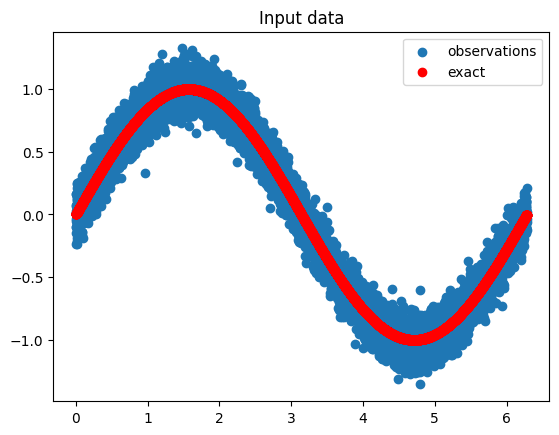

In [10]:
plt.scatter(X,y_all, label = 'observations')
plt.scatter(X, temp, color = 'red', label = 'exact')
plt.legend(loc = 'upper right')
plt.title('Input data')
#plt.savefig('1D_input.png')
plt.show()

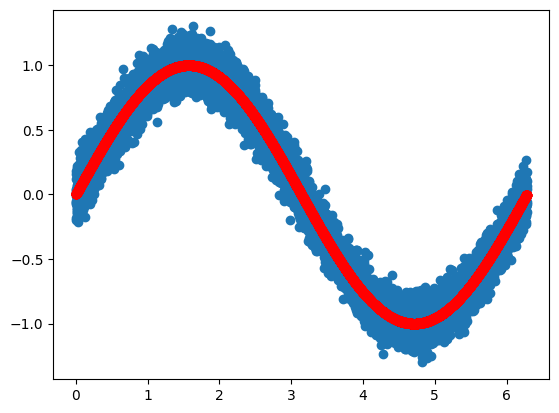

In [11]:
plt.scatter(X1,y1)
plt.scatter(X1, temp1, color = 'red')
plt.show()

In [12]:
class Config(object):
    Ntime=4 ## There are four snn parts 
    
    dim = 8
    
    x_dim=1; 
    y_dim=1; 
    
    logging_frequency = 100
    verbose = True
    y_init_range = [0, 1]
    
    num_hiddens = [dim, 16, dim]
    
def get_config(name):
    try:
        return globals()[name]
    except KeyError:
        raise KeyError("config not defined.")

cfg=get_config("Config")

In [13]:
class Dense(nn.Module):
    def __init__(self,cin,cout, batch_norm=False, activate=True): 
        super(Dense, self).__init__()
        self.cin=cin
        self.cout=cout
        self.activate=activate
        self.linear=nn.Linear(self.cin, self.cout)
        
        if batch_norm:
            self.bn=nn.BatchNorm1d(cout,eps=EPSILON,momentum=MOMENTUM)
        else:
            self.bn=None
        
    def forward(self, x):
        x=self.linear(x)
        if self.bn is not None: 
            x=self.bn(x)
        if self.activate:
            x=torch.relu(x)
        return x

class FClayerDrift(nn.Module): 
    def __init__(self,config, batch_norm=False): 
        super(FClayerDrift, self).__init__()

        self.bn=nn.BatchNorm1d(config.num_hiddens[0],eps=EPSILON,momentum=MOMENTUM)

        self.layers=[Dense(config.num_hiddens[i-1],config.num_hiddens[i]) for i in range(1, len(config.num_hiddens)-1)]
        self.layers+=[Dense(config.num_hiddens[-2], config.num_hiddens[-1], activate=False)]
        self.layers=nn.Sequential(*self.layers)
        self.dropout=nn.Dropout(0.1)
             
    def forwardX(self,x):
        x=self.layers(x) 
        return x   

In [14]:
class Dense2(nn.Module):
    def __init__(self,cin,cout, batch_norm=False, activate=True): 
        super(Dense2, self).__init__()
        self.cin=cin
        self.cout=cout
        self.activate=activate
        self.linear=nn.Linear(self.cin, self.cout)
        self.softplus=nn.Softplus()
        
        if batch_norm:
            self.bn=nn.BatchNorm1d(cout,eps=EPSILON,momentum=MOMENTUM)
        else:
            self.bn=None
        
    def forward(self, x):
        x=self.linear(x)
        if self.bn is not None: 
            x=self.bn(x)
        if self.activate:
            x=torch.relu(x)
        return x

class FClayerDiffusion(nn.Module): 
    def __init__(self,config, batch_norm=False): 
        super(FClayerDiffusion, self).__init__()
        
        self.bn=nn.BatchNorm1d(config.num_hiddens[0],eps=EPSILON,momentum=MOMENTUM)
        self.layers=[Dense2(config.num_hiddens[i-1],config.num_hiddens[i]) for i in range(1, len(config.num_hiddens)-1)]
        self.layers+=[Dense2(config.num_hiddens[-2], config.num_hiddens[-1],activate=False)]
        self.layers=nn.Sequential(*self.layers)
        self.dropout=nn.Dropout(0.1)
             
    def forwardX(self,x):
        x=self.bn(x)
        x=self.layers(x) 
       # x=self.dropout(x)
        return torch.sigmoid(x)

In [15]:
loss_fn = nn.MSELoss(reduction='mean')
class SNN(nn.Module):
    def __init__(self, config, X,y, batch_size): 
        super(SNN, self).__init__()
        self.config=config
        self.X=X
        self.driftList=nn.ModuleList([FClayerDrift(self.config) for _ in range(self.config.Ntime)])
        self.diffusionList=nn.ModuleList([FClayerDiffusion(self.config) for _ in range(self.config.Ntime)])
 
        self.project0=Dense(self.config.x_dim,self.config.dim,activate=False)
        self.project_end=Dense(self.config.dim, self.config.y_dim, activate=False)
        
        self.batch_size=batch_size
        self.h=1.0/self.config.Ntime
        self.sqrth=np.sqrt(self.h)
        self.W_p=[torch.tensor(np.random.normal(0,1, (self.X.shape[0],self.config.dim)),dtype=torch.float32, requires_grad=False).to(device) for i in range(0,self.config.Ntime)]
        self.y=torch.from_numpy(y).unsqueeze(1)

    def forwardX(self,x,idx): 
        xMat=[]
        xMat.append(x)

        x=self.project0(x)
        xMat.append(x)
        for i in range(0,self.config.Ntime):
            x=x+self.driftList[i].forwardX(x)*self.h+self.diffusionList[i].forwardX(x)*self.W_p[i][idx,:]*self.sqrth
            xMat.append(x)

        x=self.project_end(x)
        xMat.append(x)
        return xMat
      
    def backwardYZ(self,xMat,idx): ## target=
        yMat=[]
        zMat=[]

        #try to figure it later
        x_terminal=xMat[-1]
        loss=loss_fn(x_terminal,self.y[idx].to(device))
        #terminal Y_T
        y_terminal=torch.autograd.grad(outputs=[loss],inputs=[x_terminal], grad_outputs=torch.ones_like(loss), 
                                       allow_unused=True,retain_graph=True, create_graph=True)[0]
        yMat.append(y_terminal)
######## Dealing with the last layer ######## 
        xin=xMat[-2]; 
        ## here yMat[-1] is the terminal, self.project_end(xin) is also right
        hami=torch.sum(yMat[-1].detach()*self.project_end(xin),dim=1)
        ytemp=torch.autograd.grad(outputs=[hami],inputs=[xin], grad_outputs=torch.ones_like(hami), 
                                    allow_unused=True,retain_graph=True, create_graph=True)[0]
        yMat.append(ytemp)

####### Dealing with the middle layer
        for i in range(self.config.Ntime-1,-1,-1):
            xin=xMat[i+1]
            ztemp=yMat[-1]*self.W_p[i][idx,:]/self.sqrth  ### inverse order as well 
            zMat.append(ztemp)

## 4th layer eating x_4 (starting from 0)
            hami=torch.sum(yMat[-1].detach()*self.driftList[i].forwardX(xin)+ztemp.detach()*self.diffusionList[i].forwardX(xin),dim=1)
            ## this part requires analysis
            hami_x=torch.autograd.grad(outputs=[hami],inputs=[xin], grad_outputs=torch.ones_like(hami), 
                                    allow_unused=True,retain_graph=True, create_graph=True)[0]
                            
            ytemp=yMat[-1]+hami_x*self.h
            yMat.append(ytemp)

 ###### This is for the initial projection ######
        xin=xMat[0]
        hami=torch.sum(yMat[-1].detach()*self.project0(xin),dim=1)
        hami_x=torch.autograd.grad(outputs=[hami],inputs=[xin], grad_outputs=torch.ones_like(hami), 
                                    allow_unused=True,retain_graph=True, create_graph=True)[0]
        ytemp=hami_x
        yMat.append(ytemp)
        return yMat, zMat #, xMat

    def Hamcompute(self,xMat,yMat,zMat): 
        total_ham=0.0; 
        ham=torch.sum(yMat[-2].detach()*self.project0(xMat[0].detach())) ## correct
        total_ham+=ham

        for i in range(0,self.config.Ntime): 
            ham=torch.sum(yMat[self.config.Ntime-i].detach()*self.driftList[i].forwardX(xMat[i+1].detach())+zMat[i].detach()*self.diffusionList[i].forwardX(xMat[i+1].detach()))
            total_ham+=ham

        ham=torch.sum(yMat[0].detach()*self.project_end(xMat[-2].detach()))
        total_ham+=ham
        return total_ham/self.batch_size

    def predict(self,X):
        xx=X.clone()
        xMat=[]
        x=self.project0(xx)
        xMat.append(x)
        for i in range(0,self.config.Ntime):
            x=x+self.driftList[i].forwardX(x)*self.h+self.diffusionList[i].forwardX(x)*torch.FloatTensor(normal.rvs(size=[x.shape[0],self.config.dim])).to(device)*self.sqrth
            xMat.append(x)

        x=self.project_end(x)
        xMat.append(x)
        return x

    def predict_train(self,X):
        xx=X.clone()
        xMat=[]
        x=self.project0(xx)
        x=self.project0(X)
        for i in range(0,self.config.Ntime):
            x=x+self.driftList[i].forwardX(x)*self.h+self.diffusionList[i].forwardX(x)*self.W_p[i]*self.sqrth

        x=self.project_end(x)
        return x

    def predict_drift(self, X):
        xx = X.clone()
        x = self.project0(xx)
        for i in range(0, self.config.Ntime):
            x = x + self.driftList[i].forwardX(x) * self.h
        x = self.project_end(x)
        return x


In [16]:
def training(model, X):
    optimizer = torch.optim.Adam(model.parameters(), lr = 1e-4, weight_decay = 1e-8)
    loss_history = []
    for e in range(epoch): 
        shuffle_idx=np.arange(X.shape[0])
        np.random.shuffle(shuffle_idx)
        epoch_loss=[]
        
        optimizer.zero_grad()
        indices=np.random.randint(0, X.shape[0], size=batch_size) 
        batch_x=X[indices,:].to(device)
        
        xmat=model.forwardX(batch_x,indices)
        ymat,zmat=model.backwardYZ(xmat,indices)
        loss_temp=model.Hamcompute(xmat,ymat,zmat)
        
        loss_temp.backward()
        optimizer.step()
        epoch_loss.append(loss_temp.cpu().detach().numpy())        
        
        epoch_loss =  np.mean(epoch_loss)
        loss_history.append(epoch_loss)

    return model

In [17]:
def FedAvg(w):
    w_avg = copy.deepcopy(w[0])
    for k in w_avg.keys():
        for i in range(1, len(w)):
            w_avg[k] += w[i][k]
        w_avg[k] = torch.div(w_avg[k], len(w))
    return w_avg

In [18]:
if type(X) == np.ndarray:
    XX=torch.tensor(X,requires_grad=True)

In [19]:
rich_size = 50
sparse_size = 10
local_size = rich_size + sparse_size
batch_size = 16
model=SNN(cfg,XX,y_all,batch_size).to(device);
epoch=5000; 
from torch.optim.lr_scheduler import MultiStepLR

In [20]:
w_global = model.state_dict()
w_local = [copy.deepcopy(w_global) for _ in range(100)]

In [21]:
w_count = {}
for i in range(100):
    w_count[str(i)] = 0

In [22]:
indices_x = []
for i in range(100):
    if i < 10: 
        indices_x.append(np.concatenate((np.random.choice(range(1000), size = rich_size, replace = False), 
                                         np.random.choice(range(1000, 10000), size = sparse_size, replace = False)), axis = None))
    elif i > 89:
        indices_x.append(np.concatenate((9000 + np.random.choice(range(1000), size = rich_size, replace = False), 
                                         np.random.choice(range(9000), size = sparse_size, replace = False)), axis = None))
    else:
        indices_x.append(np.concatenate((i // 10 * 1000 + np.random.choice(range(1000), size = rich_size, replace = False), 
                                         np.random.choice(list(range(0, i // 10 * 1000)) + list(range((i // 10 + 1) * 1000, 10000)), 
                                                          size = sparse_size, replace = False)), axis = None))

In [23]:
noise_y = []
for i in range(100):
    noise_y.append(np.random.normal(0, 1, size = local_size))

  0%|          | 0/10 [00:00<?, ?it/s]

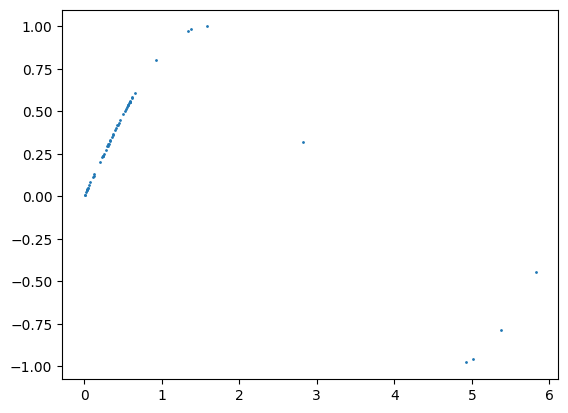

 10%|█         | 1/10 [00:00<00:01,  6.32it/s]

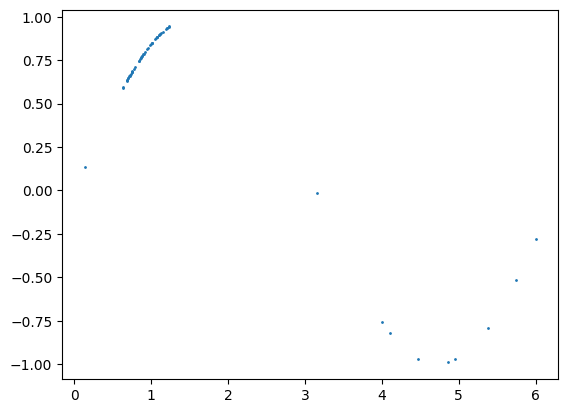

 20%|██        | 2/10 [00:00<00:01,  6.54it/s]

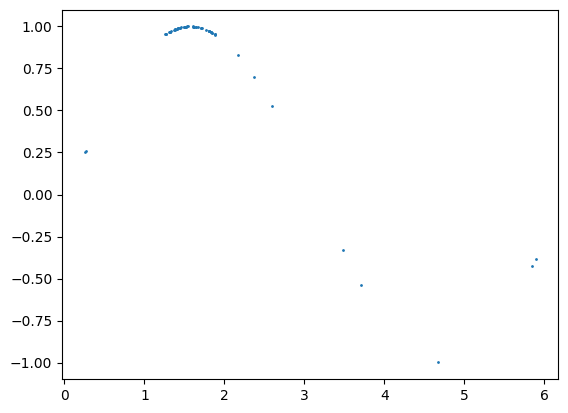

 30%|███       | 3/10 [00:00<00:01,  6.67it/s]

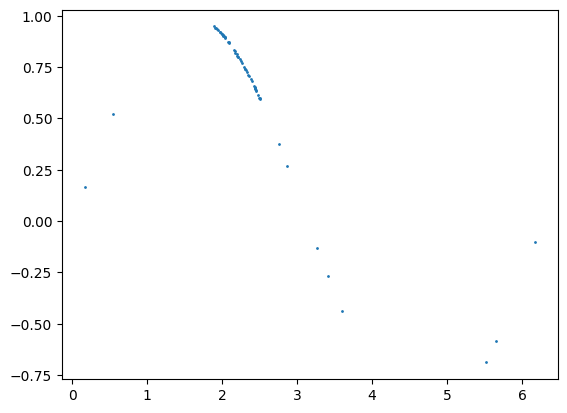

 40%|████      | 4/10 [00:00<00:00,  6.78it/s]

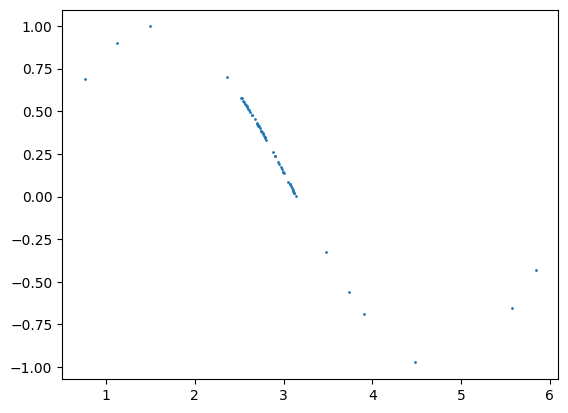

 50%|█████     | 5/10 [00:00<00:00,  6.84it/s]

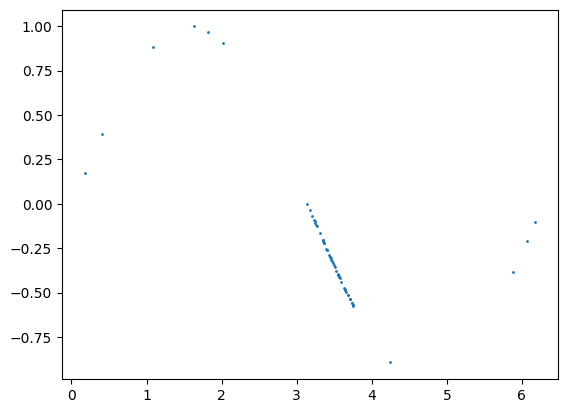

 60%|██████    | 6/10 [00:00<00:00,  6.87it/s]

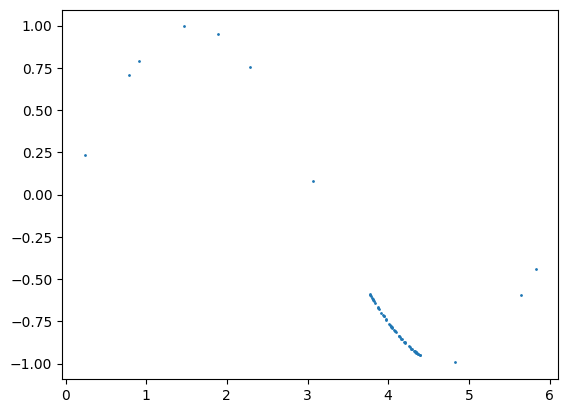

 70%|███████   | 7/10 [00:01<00:00,  6.84it/s]

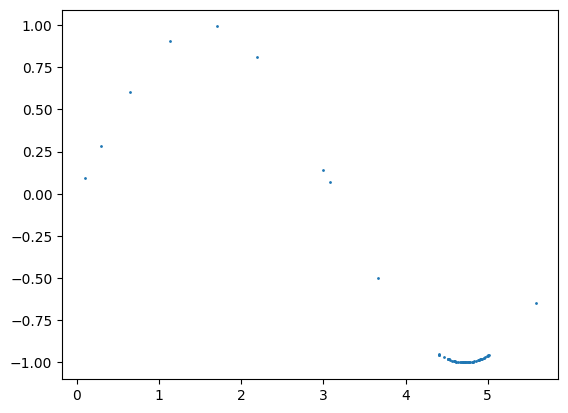

 80%|████████  | 8/10 [00:01<00:00,  6.83it/s]

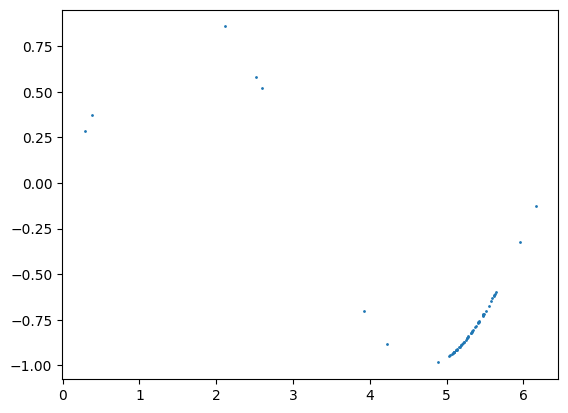

 90%|█████████ | 9/10 [00:01<00:00,  6.90it/s]

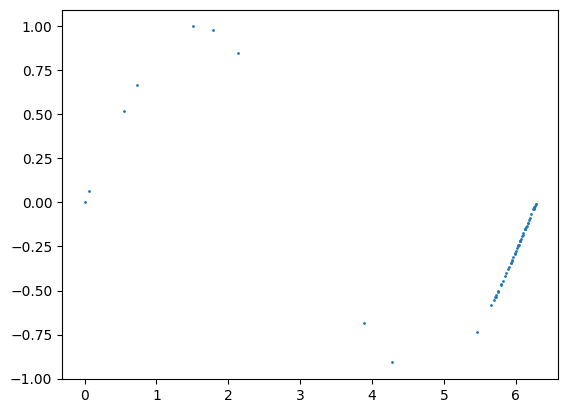

100%|██████████| 10/10 [00:01<00:00,  6.79it/s]


In [24]:
for i in tqdm(range(10)):
    plt.figure()
    plt.scatter(XX[indices_x[i * 10], :].cpu().detach().numpy(), exact[indices_x[i * 10]], s = 1)
    plt.show()

In [25]:
model1 = SNN(cfg,XX,y_all,batch_size).to(device)
true_error = []

 90%|█████████ | 9/10 [2:46:48<18:30, 1110.09s/it]  

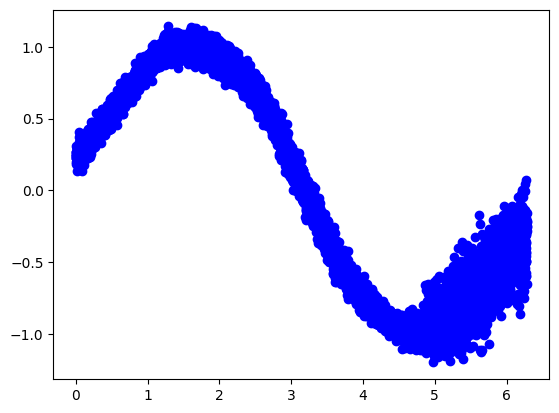

100%|██████████| 10/10 [3:05:25<00:00, 1112.54s/it]


In [26]:
for i in tqdm(range(10)):
    idxs_users = np.random.choice(range(100), 10, replace = False)
    temp_model = []
    for idx in idxs_users:
        w_count[str(idx)] = w_count[str(idx)] + 1
        #np.random.seed(idx) 
        #indices = np.random.randint(0, XX.shape[0], size = local_size)
        indices = indices_x[idx]
        XXX = XX[indices, :]
        #noise = np.random.normal(0, 1, size = exact.shape)
        noise = noise_y[idx]
        #y = exact + noise * 0.2
        y = exact[indices]
        y = y + noise * 0.1
        y = y.astype(np.float32)
        temp = SNN(cfg, XXX, y, batch_size).to(device)
        temp.load_state_dict(w_local[idx])
        temp = training(temp, XXX)
        #w_local[idx] = copy.deepcopy(temp.state_dict())
        temp_model.append(copy.deepcopy(temp.state_dict()))
        
    w_global = FedAvg(temp_model)
    model.load_state_dict(w_global)
    vt = model1.predict(XX.to(device)).cpu().detach().numpy()
    true_error.append(copy.deepcopy(np.square(f(X).ravel() - vt.ravel()).sum() / f(X).ravel().shape[0]))
    j = 0
    if i != 9:
        for j in range(len(w_local)):
            w_local[j] = copy.deepcopy(w_global)
    if (i + 1) % 10 == 0:
        model1.load_state_dict(w_global)
        vt = model1.predict(XX.to(device)).cpu().detach().numpy()
        plt.scatter(XX.cpu().detach().numpy(), vt, color = 'b', label = 'predicted')
        plt.show()
#w_global = FedAvg(w_local)
#model.load_state_dict(w_global)

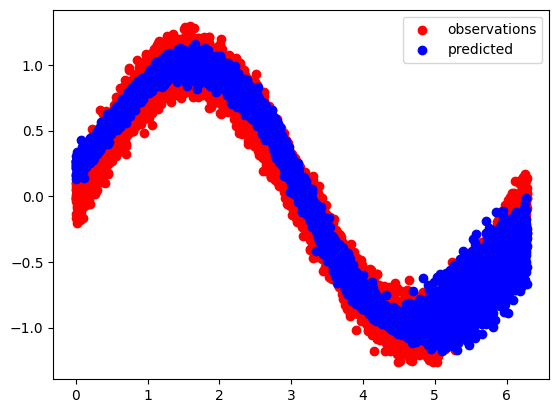

In [30]:
model1.load_state_dict(w_global)
vt = model1.predict(XX.to(device)).cpu().detach().numpy()
plt.scatter(X,y_all, color = 'red', label = 'observations')
plt.scatter(XX.cpu().detach().numpy(), vt, color = 'b', label = 'predicted')
plt.legend(loc = 'upper right')
plt.show()

In [31]:
torch.save(w_global, "FedSNN_1D_global.pth")

In [26]:
w_global = torch.load("FedSNN_1D_global.pth")

In [27]:
model1.load_state_dict(w_global)

<All keys matched successfully>

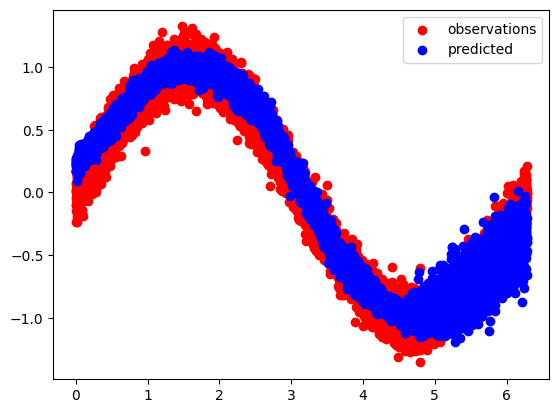

In [28]:
vt = model1.predict(XX.to(device)).cpu().detach().numpy()
plt.scatter(X,y_all, color = 'red', label = 'observations')
plt.scatter(XX.cpu().detach().numpy(), vt, color = 'b', label = 'predicted')
plt.legend(loc = 'upper right')
plt.show()

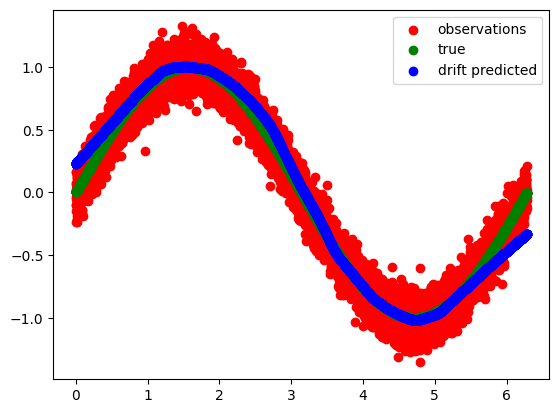

In [29]:
vs = model1.predict_drift(XX.to(device)).cpu().detach().numpy()
plt.scatter(X,y_all, color = 'red', label = 'observations')
plt.scatter(X, f(X), color = 'green', label = 'true')
plt.scatter(XX.cpu().detach().numpy(), vs, color = 'b', label = 'drift predicted')
plt.legend(loc = 'upper right')
plt.show()

In [30]:
np.square(f(X).ravel() - vt.ravel()).sum() / X.shape[0]

np.float32(0.013774334)

In [31]:
np.square(f(X).ravel() - vs.ravel()).sum() / X.shape[0]

np.float32(0.007217015)

In [32]:
np.square(f(X).ravel() - f(X).ravel() + 0.1 * np.random.normal(0, 1, X.shape[0])).sum() / X.shape[0]

np.float64(0.009940689794026847)

In [43]:
loss_fn(model1.predict(XX.to(device)), torch.from_numpy(f(X)).to(device))

tensor(0.0136, device='cuda:0', grad_fn=<MseLossBackward0>)